# Learned grounding vs post-hoc attribution



## 1. Setup

In [ ]:
!pip install -q transformers accelerate bitsandbytes peft datasets scipy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 MB 24.1 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys, json, time, math, random, hashlib, shutil, subprocess
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset
from PIL import Image, ImageFilter
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

OUT_ROOT = "/content/drive/MyDrive/MSC_VLM_GROUNDED"
device = "cuda" if torch.cuda.is_available() else "cpu"
GRID = 37
print("device:", device)

PNG_TAR, PNG_LOCAL = f"{OUT_ROOT}/pcgr_png.tar", "/content/pc_png"
if not os.path.exists(f"{PNG_LOCAL}/manifest.json"):
    if not os.path.isdir(PNG_LOCAL) or len(os.listdir(PNG_LOCAL)) < 100:
        subprocess.run(["tar", "-xf", PNG_TAR, "-C", "/content"])
    if not os.path.exists(f"{PNG_LOCAL}/manifest.json"):
        shutil.copy(f"{OUT_ROOT}/manifest.json", f"{PNG_LOCAL}/manifest.json")
pc_all = json.load(open(f"{PNG_LOCAL}/manifest.json"))
print(f"{len(pc_all)} studies")

Mounted at /content/drive
device: cuda
4555 studies


## 2. Definitions

In [ ]:
import re

class CFG:
    SEED = 42

    # vision
    IMG_SIZE = 518
    PATCH = 14
    RAW_GRID = 37                  # 518 / 14
    POOL_GRID = 19                 # 361 tokens — fits a T4; keeps raster order
    VISION_DIM = 768

    # coordinate vocabulary
    COORD_BINS = 32                # -> 64 tokens (32 x + 32 y)

    # llm
    LLM_ID = "Qwen/Qwen2.5-3B-Instruct"
    LORA_R = 32
    LORA_ALPHA = 64
    LORA_DROPOUT = 0.05
    LORA_TARGETS = ["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"]

    # training — IDENTICAL across runs
    EPOCHS = 1                     # checkpoints every 300 steps
    BATCH = 1
    ACCUM = 8                     # effective batch 16
    LR = 2e-6
    LR_ADAPTER = 5e-5
    WARMUP_FRAC = 0.03
    MAX_LEN = 512
    GROUNDED_FRACTION = 1.0        # abnormal-only run: every sample grounded

    # decoding
    MAX_NEW_TOKENS = 220
    DO_SAMPLE = True
    TOP_P = 0.9
    TEMPERATURE = 0.7


def seed_everything(s=CFG.SEED):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)


# ==============================================================================
# PROMPTS
# ==============================================================================

SYSTEM = ("<|im_start|>system\nYou are an expert radiology assistant tasked "
          "with interpreting a chest X-ray study.<|im_end|>\n")

INSTR_FINDGEN = (
    "<|im_start|>user\nProvide a description of the findings in the radiology "
    "study. Each finding should be described as a self-contained plain-text "
    "sentence.<|im_end|>\n<|im_start|>assistant\n")

INSTR_GROUNDREP = (
    "<|im_start|>user\nProvide a description of the findings in the radiology "
    "study. Each finding should be described as a self-contained plain-text "
    "sentence. If the finding is groundable, locate it in the image with "
    "bounding boxes indicating all locations where it can be seen. Otherwise "
    "generate just the ungrounded finding.<|im_end|>\n<|im_start|>assistant\n")


# ==============================================================================
# COORDINATE VOCABULARY
# ==============================================================================

OBJ_OPEN, OBJ_CLOSE = "<obj>", "</obj>"
BOX_OPEN, BOX_CLOSE = "<box>", "</box>"


def coord_tokens(n=CFG.COORD_BINS):
    return ([f"<x{i}>" for i in range(n)] + [f"<y{i}>" for i in range(n)]
            + [OBJ_OPEN, OBJ_CLOSE, BOX_OPEN, BOX_CLOSE])


def add_coord_tokens(tokenizer, model, n=CFG.COORD_BINS):

    new = coord_tokens(n)
    added = tokenizer.add_tokens(new, special_tokens=True)
    if added == 0:
        return tokenizer, model
    model.resize_token_embeddings(len(tokenizer))
    with torch.no_grad():
        emb = model.get_input_embeddings().weight
        old = emb[:-added].float()
        mu, sd = old.mean(0, keepdim=True), old.std(0, keepdim=True)
        emb[-added:] = (mu + torch.randn(added, emb.shape[1],
                                         device=emb.device) * sd).to(emb.dtype)
        out = model.get_output_embeddings()
        if out is not None and out.weight.data_ptr() != emb.data_ptr():
            o = out.weight[:-added].float()
            om, os_ = o.mean(0, keepdim=True), o.std(0, keepdim=True)
            out.weight[-added:] = (om + torch.randn(added, o.shape[1],
                                                    device=o.device) * os_
                                   ).to(out.weight.dtype)
        chk = emb[-added:]
        spread = chk.float().std(0).mean().item()
    print(f"added {added} tokens | vocab {len(tokenizer)} | "
          f"new-row spread {spread:.5f} (must be > 0)")
    assert spread > 1e-4, "coordinate tokens are identical — init failed"
    return tokenizer, model


def box_to_tokens(box_norm, n=CFG.COORD_BINS):
    """(x0,y0,x1,y1) normalised to [0,1] -> '<x><y><x><y>' token string."""
    x0, y0, x1, y1 = box_norm
    q = lambda v: int(np.clip(round(v * (n - 1)), 0, n - 1))
    return f"<x{q(x0)}><y{q(y0)}><x{q(x1)}><y{q(y1)}>"


BOX_RE = re.compile(r"<x(\d+)><y(\d+)><x(\d+)><y(\d+)>")


def parse_generation(text, n=CFG.COORD_BINS):
    """
    Decode model output -> [(sentence, [boxes_norm])].
    A sentence with no <box> is an ABSTENTION, which is a valid output.
    """
    out = []
    for chunk in re.findall(r"<obj>(.*?)</obj>", text, flags=re.S):
        boxes = [(int(a)/(n-1), int(b)/(n-1), int(c)/(n-1), int(d)/(n-1))
                 for a, b, c, d in BOX_RE.findall(chunk)]
        sent = re.sub(r"<box>.*?</box>", "", chunk, flags=re.S)
        sent = BOX_RE.sub("", sent).strip()
        if sent:
            out.append((sent, boxes))
    if not out and text.strip():                  # ungrounded fallback
        out = [(text.strip(), [])]
    return out


# ==============================================================================
# GEOMETRY — image and boxes through the identical transform
# ==============================================================================

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], np.float32)
IMAGENET_STD = np.array([0.229, 0.224, 0.225], np.float32)


def preprocess(pil_img, boxes_xyxy=None, size=CFG.IMG_SIZE):

    W, H = pil_img.size
    scale = size / min(W, H)
    nw, nh = int(round(W * scale)), int(round(H * scale))
    img = pil_img.convert("RGB").resize((nw, nh), Image.BILINEAR)
    ox, oy = max(0, (nw - size) // 2), max(0, (nh - size) // 2)
    img = img.crop((ox, oy, ox + size, oy + size))

    arr = np.asarray(img, np.float32) / 255.0
    arr = (arr - IMAGENET_MEAN) / IMAGENET_STD
    px = torch.from_numpy(arr).permute(2, 0, 1)

    if boxes_xyxy is None:
        return px, None, img

    out = []
    for b in boxes_xyxy:
        nb = (b[0]*scale - ox, b[1]*scale - oy, b[2]*scale - ox, b[3]*scale - oy)
        cl = (max(0., nb[0]), max(0., nb[1]),
              min(float(size), nb[2]), min(float(size), nb[3]))
        oa = max(1e-6, (nb[2]-nb[0]) * (nb[3]-nb[1]))
        sa = max(0., cl[2]-cl[0]) * max(0., cl[3]-cl[1])
        out.append(tuple(v / size for v in cl) if sa/oa >= 0.30 else None)
    return px, out, img




In [ ]:
# ==============================================================================
# TARGET FORMATTING
# ==============================================================================

def format_findgen(sentences):
    """Run A, and the ungrounded half of Run B."""
    return " ".join(s.strip() for s in sentences if s.strip())


def format_groundrep(sentences, boxes_per_sentence):
    """
    Run B grounded target:
        <obj>There is a right pleural effusion.<box><x12><y20><x25><y28></box></obj>
        <obj>No pneumothorax.</obj>          <- abstention, no box tokens
    """
    parts = []
    for sent, boxes in zip(sentences, boxes_per_sentence):
        s = sent.strip()
        if not s:
            continue
        valid = [b for b in boxes if b is not None]
        if valid:
            btxt = "".join(BOX_OPEN + box_to_tokens(b) + BOX_CLOSE for b in valid)
            parts.append(f"{OBJ_OPEN}{s}{btxt}{OBJ_CLOSE}")
        else:
            parts.append(f"{OBJ_OPEN}{s}{OBJ_CLOSE}")
    return "".join(parts)


# ==============================================================================
# ABSTENTION — three categories, per the MAIRA-2 protocol
# ==============================================================================

NEGATION_CUES = ["no ", "not ", "without", "free of", "clear of", "negative for",
                 "absence of", "absent", "unremarkable", "normal limits",
                 "within normal", "no evidence"]
NORMALITY_CUES = ["are clear", "is clear", "is normal", "are normal",
                  "unremarkable", "within normal limits", "no abnormalit",
                  "intact", "well-inflated", "well expanded"]
NON_LOCALISABLE_CUES = ["diffuse", "generalised", "generalized", "widespread",
                        "throughout", "global", "hyperinflat", "hypoinflat",
                        "low lung volumes", "emphysema", "copd", "osteopenia",
                        "deminerali", "scoliosis"]


def is_groundable(sentence):
    s = " " + sentence.lower().strip() + " "
    if any(c in s for c in NEGATION_CUES):        return False
    if any(c in s for c in NORMALITY_CUES):       return False
    if any(c in s for c in NON_LOCALISABLE_CUES): return False
    return True


# ==============================================================================
# SPLITS
# ==============================================================================

def study_key(text):
    """
    IU X-ray has no patient ID and is flattened one row per IMAGE. Frontal and
    lateral of one study share the SAME report string, so hashing the
    normalised report recovers study-level grouping. Without this the frontal
    lands in train and the lateral in test with identical target text.
    """
    return hashlib.md5(re.sub(r"\s+", " ", (text or "").strip().lower())
                       .encode()).hexdigest()


def group_split(keys, frac=(0.8, 0.1, 0.1), seed=CFG.SEED):
    uniq = sorted(set(keys)); random.Random(seed).shuffle(uniq)
    n, a, b = len(uniq), int(len(uniq)*frac[0]), int(len(uniq)*(frac[0]+frac[1]))
    assign = {k: ("train" if i < a else "val" if i < b else "test")
              for i, k in enumerate(uniq)}
    out = {"train": [], "val": [], "test": []}
    for i, k in enumerate(keys):
        out[assign[k]].append(i)
    return out


def symmetry_score(pil_img, size=128):
    """Frontal CXRs are near left-right symmetric; laterals are not."""
    a = np.asarray(pil_img.convert("L").resize((size, size)), np.float32)
    b = a[:, ::-1]
    a = (a - a.mean()) / (a.std() + 1e-8)
    b = (b - b.mean()) / (b.std() + 1e-8)
    return float((a * b).mean())


FRONTAL_THRESHOLD = 0.68

In [ ]:
class SpatialMLPAdapter(nn.Module):


    def __init__(self, vision_dim=CFG.VISION_DIM, llm_dim=2048,
                 raw_grid=CFG.RAW_GRID, pool_grid=CFG.POOL_GRID,
                 target_norm=1.0):
        super().__init__()
        self.raw_grid, self.pool_grid = raw_grid, pool_grid
        self.proj = nn.Linear(vision_dim, llm_dim)
        self.norm = nn.LayerNorm(llm_dim)
        self.scale = nn.Parameter(torch.tensor(target_norm / (llm_dim ** 0.5)))

    def forward(self, rad_out):
        x = rad_out[:, 1:, :]
        B, N, C = x.shape
        assert N == self.raw_grid ** 2, (
            f"expected {self.raw_grid**2} patches, got {N}")
        x = x.transpose(1, 2).reshape(B, C, self.raw_grid, self.raw_grid)
        x = F.adaptive_avg_pool2d(x, (self.pool_grid, self.pool_grid))
        x = x.flatten(2).transpose(1, 2)
        return self.norm(self.proj(x)) * self.scale


seed_everything()
print("adapter class ready")

adapter class ready


In [ ]:
def patient_level_split(manifest, frac=(0.80, 0.10, 0.10), seed=42):
    groups = {}
    for m in manifest:
        groups.setdefault(str(m["patient_id"]), []).append(m)
    abn = [k for k, v in groups.items() if any(x["abnormal"] for x in v)]
    nrm = [k for k, v in groups.items() if not any(x["abnormal"] for x in v)]
    rng = random.Random(seed); rng.shuffle(abn); rng.shuffle(nrm)
    out = {"train": [], "val": [], "test": []}
    ids = {"train": set(), "val": set(), "test": set()}
    for pool in (abn, nrm):
        a, b = int(len(pool)*frac[0]), int(len(pool)*(frac[0]+frac[1]))
        for nm, ks in [("train", pool[:a]), ("val", pool[a:b]), ("test", pool[b:])]:
            for k in ks:
                out[nm].extend(groups[k]); ids[nm].add(k)
    assert ids["train"].isdisjoint(ids["val"])
    assert ids["train"].isdisjoint(ids["test"])
    assert ids["val"].isdisjoint(ids["test"])
    return out["train"], out["val"], out["test"]


pc_train, pc_val, pc_test = patient_level_split(pc_all)
tr_abn = [m for m in pc_train if m["abnormal"]]
va_abn = [m for m in pc_val   if m["abnormal"]]
te_abn = [m for m in pc_test  if m["abnormal"]]

ns = sum(len(m["sentences"]) for m in tr_abn)
ng = sum(sum(1 for b in m["boxes"] if b) for m in tr_abn)
print(f"ABNORMAL-ONLY  train {len(tr_abn)} | val {len(va_abn)} | test {len(te_abn)}")
print(f"train sentences {ns} | with box {ng} ({100*ng/ns:.1f}%)")
print("\n(full split was 3643/456/456 at 68.0% abnormal)")

pc_train, pc_val, pc_test = patient_level_split(pc_all)
te_abn = [m for m in pc_test if m["abnormal"]]
print(f"test abnormal: {len(te_abn)}")

ABNORMAL-ONLY  train 2479 | val 310 | test 310
train sentences 6955 | with box 5034 (72.4%)

(full split was 3643/456/456 at 68.0% abnormal)
test abnormal: 310


## 3. Load the model

In [ ]:
def build_model():
    from transformers import (AutoModel, AutoTokenizer, AutoModelForCausalLM,
                              BitsAndBytesConfig)
    from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

    print("Rad-DINO (frozen)...")
    vision = AutoModel.from_pretrained("microsoft/rad-dino").to(device).eval()
    for p in vision.parameters():
        p.requires_grad = False

    print("Qwen2.5-3B (4-bit) + LoRA...")
    tok = AutoTokenizer.from_pretrained(CFG.LLM_ID)
    tok.pad_token = tok.eos_token
    tok.padding_side = "right"
    bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_use_double_quant=True,
                             bnb_4bit_quant_type="nf4",
                             bnb_4bit_compute_dtype=torch.float16)
    base = AutoModelForCausalLM.from_pretrained(
        CFG.LLM_ID, quantization_config=bnb, device_map={"": 0})


    tok, base = add_coord_tokens(tok, base)
    base = prepare_model_for_kbit_training(base)


    lora = LoraConfig(r=CFG.LORA_R, lora_alpha=CFG.LORA_ALPHA,
                      lora_dropout=CFG.LORA_DROPOUT, bias="none",
                      task_type="CAUSAL_LM", target_modules=CFG.LORA_TARGETS)
    llm = get_peft_model(base, lora)
    llm.config.use_cache = False
    llm.gradient_checkpointing_enable()
    llm.enable_input_require_grads()


    n_new = len(coord_tokens())
    emb = llm.get_input_embeddings()
    emb.weight.requires_grad_(True)
    mask = torch.zeros(emb.weight.shape[0], 1,
                       device=emb.weight.device, dtype=emb.weight.dtype)
    mask[-n_new:] = 1.0
    emb.weight.register_hook(lambda g: g * mask)
    llm._n_new_tokens = n_new

    adapter = SpatialMLPAdapter(llm_dim=llm.config.hidden_size).to(device)

    n_ad = sum(p.numel() for p in adapter.parameters())
    n_lora = sum(p.numel() for n, p in llm.named_parameters()
                 if p.requires_grad and "embed_tokens" not in n)
    n_emb_eff = n_new * emb.weight.shape[1]        # effective, after masking
    n_frozen = sum(p.numel() for p in llm.parameters()) \
        + sum(p.numel() for p in vision.parameters())
    tot = n_ad + n_lora + n_emb_eff
    print(f"\nTRAINABLE PARAMETERS")
    print(f"  MLP adapter          {n_ad:>12,}")
    print(f"  LoRA (r={CFG.LORA_R})           {n_lora:>12,}")
    print(f"  coord embeddings     {n_emb_eff:>12,}  "
          f"({n_new} tokens x {emb.weight.shape[1]})")
    print(f"  ------------------------------------")
    print(f"  total trainable      {tot:>12,}  ({100*tot/max(1,n_frozen):.2f}% "
          f"of the frozen backbone)")
    return vision, tok, llm, adapter

In [ ]:
@torch.no_grad()
def encode_image(vision, px):
    return vision(px.to(device)).last_hidden_state


RUN, CKPT = "run_B_final_ep23", "ep2_final.pt"
from peft import set_peft_model_state_dict

vision, tok, llm, adapter = build_model()
st = torch.load(f"{OUT_ROOT}/{RUN}/{CKPT}", map_location=device,
                weights_only=False)
adapter.load_state_dict(st["adapter"])
set_peft_model_state_dict(llm, st["lora"])
with torch.no_grad():
    w = llm.get_input_embeddings().weight
    w[-68:] = st["coord"].to(w.dtype).to(w.device)
llm.eval(); adapter.eval()
print(f"loaded {RUN}/{CKPT}")

Rad-DINO (frozen)...


config.json:   0%|          | 0.00/879 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

added 68 tokens | vocab 151733 | new-row spread 0.02339 (must be > 0)

TRAINABLE PARAMETERS
  MLP adapter             1,579,009
  LoRA (r=32)             59,867,136
  coord embeddings          139,264  (68 tokens x 2048)
  ------------------------------------
  total trainable        61,585,409  (3.34% of the frozen backbone)
loaded run_B_final_ep23/ep2_final.pt


## 4. Attribution target



In [ ]:
def encode_for_grad(study):
    """Patch tensor with requires_grad, plus the frozen forward context."""
    px, _, _ = preprocess(Image.open(study["path"]))
    with torch.no_grad():
        rad = vision(px[None].to(device)).last_hidden_state
    return rad.detach().clone().requires_grad_(True)


def target_score(rad_patches, sentence):
    """S = mean log P(sentence tokens | visual prefix)."""
    vis = adapter(rad_patches.float())
    prompt = SYSTEM + INSTR_GROUNDREP + "<obj>"
    ids = tok(prompt + sentence, return_tensors="pt",
              truncation=True, max_length=CFG.MAX_LEN)["input_ids"].to(device)
    n_prompt = len(tok(prompt, add_special_tokens=False)["input_ids"])
    emb = llm.get_input_embeddings()(ids)
    inp = torch.cat([vis.to(emb.dtype), emb], dim=1)
    logits = llm(inputs_embeds=inp,
                 attention_mask=torch.ones(inp.shape[:2], dtype=torch.long,
                                           device=device)).logits
    lp = torch.log_softmax(logits.float(), -1)
    n_vis = vis.shape[1]
    tot, cnt = 0.0, 0
    for t in range(n_prompt, ids.shape[1]):
        pos = n_vis + t - 1
        if 0 <= pos < lp.shape[1]:
            tot = tot + lp[0, pos, ids[0, t]]; cnt += 1
    return tot / cnt if cnt else None


# does the target discriminate? gradients are only meaningful if it does
s0 = next(m for m in te_abn if any(m["boxes"]))
sent0 = next(t for t, b in zip(s0["sentences"], s0["boxes"]) if b)
r0 = encode_for_grad(s0)
with torch.no_grad():
    v_true = target_score(r0.detach(), sent0).item()
    v_other = target_score(r0.detach(), "There is a large pneumothorax.").item()
print(f"log P(reference sentence) {v_true:.3f}")
print(f"log P(unrelated sentence) {v_other:.3f}")
print(f"gap {v_true - v_other:+.3f}  (positive = target carries signal)")

log P(reference sentence) -2.520
log P(unrelated sentence) -1.950
gap -0.570  (positive = target carries signal)


In [ ]:
sent = "There is a right pleural effusion."
scores = []
for s in te_abn[:20]:
    r = encode_for_grad(s)
    with torch.no_grad():
        scores.append(target_score(r.detach(), sent).item())
scores = np.array(scores)
print(f"same sentence, 20 images: mean {scores.mean():.3f} sd {scores.std():.3f}")
print(f"range {scores.min():.3f} to {scores.max():.3f}")
print("  sd near 0 -> S is image-independent; gradients would be meaningless")

same sentence, 20 images: mean -1.389 sd 0.034
range -1.461 to -1.334
  sd near 0 -> S is image-independent; gradients would be meaningless


In [ ]:
def target_box_score(rad_patches, sentence, box_norm):
    """S over COORDINATE tokens only — the part of the output that
    demonstrably depends on the image."""
    vis = adapter(rad_patches.float())
    n = CFG.COORD_BINS
    q = lambda v: int(np.clip(round(v*(n-1)), 0, n-1))
    box_str = (f"<x{q(box_norm[0])}><y{q(box_norm[1])}>"
               f"<x{q(box_norm[2])}><y{q(box_norm[3])}>")
    prefix = SYSTEM + INSTR_GROUNDREP + f"<obj>{sentence}<box>"
    ids = tok(prefix + box_str, return_tensors="pt")["input_ids"].to(device)
    n_pre = len(tok(prefix, add_special_tokens=False)["input_ids"])
    emb = llm.get_input_embeddings()(ids)
    inp = torch.cat([vis.to(emb.dtype), emb], dim=1)
    lg = llm(inputs_embeds=inp,
             attention_mask=torch.ones(inp.shape[:2], dtype=torch.long,
                                       device=device)).logits
    lp = torch.log_softmax(lg.float(), -1)
    nv = vis.shape[1]
    tot, cnt = 0.0, 0
    for t in range(n_pre, ids.shape[1]):
        pos = nv + t - 1
        if 0 <= pos < lp.shape[1]:
            tot = tot + lp[0, pos, ids[0, t]]; cnt += 1
    return tot / cnt if cnt else None


# same box, different images — does S move now?
s_ref = next(m for m in te_abn if any(m["boxes"]))
sent = next(t for t, b in zip(s_ref["sentences"], s_ref["boxes"]) if b)
box = (0.3, 0.3, 0.6, 0.6)

sc = []
for s in te_abn[:20]:
    r = encode_for_grad(s)
    with torch.no_grad():
        v = target_box_score(r.detach(), sent, box)
    if v is not None: sc.append(v.item())
sc = np.array(sc)
print(f"same box, 20 images: mean {sc.mean():.3f} sd {sc.std():.3f}")
print(f"  text target had sd 0.034 — want clearly higher")

same box, 20 images: mean -3.539 sd 0.140
  text target had sd 0.034 — want clearly higher


In [ ]:
gaps = []
for s in te_abn[:20]:
    gt = next((b for b in s["boxes"] if b), None)
    if gt is None: continue
    sent = next(t for t, b in zip(s["sentences"], s["boxes"]) if b)
    W, H = Image.open(s["path"]).size
    g = gt[0]; gn = (g[0]/W, g[1]/H, g[2]/W, g[3]/H)
    wrong = (1-gn[2], 1-gn[3], 1-gn[0], 1-gn[1])   # mirrored
    r = encode_for_grad(s)
    with torch.no_grad():
        a = target_box_score(r.detach(), sent, gn)
        b_ = target_box_score(r.detach(), sent, wrong)
    if a is not None and b_ is not None: gaps.append(a.item()-b_.item())
gaps = np.array(gaps)
print(f"correct vs mirrored box: mean gap {gaps.mean():+.3f} | "
      f"positive {100*(gaps>0).mean():.0f}%")

correct vs mirrored box: mean gap -0.002 | positive 58%


In [ ]:
gaps = []
for s in te_abn[:20]:
    gt = next((b for b in s["boxes"] if b), None)
    if gt is None: continue
    sent = next(t for t, b in zip(s["sentences"], s["boxes"]) if b)
    W, H = Image.open(s["path"]).size
    g = gt[0]; gn = (g[0]/W, g[1]/H, g[2]/W, g[3]/H)
    corner = (0.02, 0.02, 0.20, 0.20)          # outside the thorax entirely
    r = encode_for_grad(s)
    with torch.no_grad():
        a = target_box_score(r.detach(), sent, gn)
        b_ = target_box_score(r.detach(), sent, corner)
    if a is not None and b_ is not None: gaps.append(a.item() - b_.item())
gaps = np.array(gaps)
print(f"correct vs corner: mean {gaps.mean():+.3f} | positive {100*(gaps>0).mean():.0f}%")

correct vs corner: mean +1.157 | positive 89%


In [ ]:
gaps = []
for s in te_abn[:30]:
    sent = next((t for t, b in zip(s["sentences"], s["boxes"]) if b), None)
    if sent is None: continue
    r = encode_for_grad(s)
    with torch.no_grad():
        v_t = target_score(r.detach(), sent).item()
        v_o = target_score(r.detach(), "There is a large pneumothorax.").item()
    gaps.append(v_t - v_o)
gaps = np.array(gaps)
print(f"n={len(gaps)} | mean {gaps.mean():+.3f} | positive {100*(gaps>0).mean():.0f}%")

n=28 | mean -0.020 | positive 57%


## 5. Attribution methods

All three attribute the same scalar to the same patch tensor. The only
difference is how gradients or activations are combined.

In [ ]:
def _grads(study, sentence, box_norm):

    rad = encode_for_grad(study)
    S = target_box_score(rad, sentence, box_norm)
    if S is None: return None, None
    llm.zero_grad(set_to_none=True); adapter.zero_grad(set_to_none=True)
    S.backward()
    return rad.grad[0, 1:, :].detach(), rad[0, 1:, :].detach()


def cam_hirescam(study, sentence, box_norm):
    g, a = _grads(study, sentence, box_norm)
    return None if g is None else (g * a).sum(-1).cpu().numpy()


def cam_gradcam(study, sentence, box_norm):
    g, a = _grads(study, sentence, box_norm)
    return None if g is None else (g.mean(0, keepdim=True) * a).sum(-1).cpu().numpy()

@torch.no_grad()
def cam_scorecam(study, sentence, box_norm, n_channels=32):

    rad = encode_for_grad(study).detach()
    a = rad[0, 1:, :]
    idx = torch.topk(a.norm(dim=0), min(n_channels, a.shape[1])).indices
    base = target_box_score(rad, sentence, box_norm)
    if base is None:
        return None
    base = float(base)
    cam = torch.zeros(a.shape[0], device=a.device)
    for c in idx:
        m = a[:, c]
        m = (m - m.min()) / (m.max() - m.min() + 1e-8)
        pert = rad.clone()
        pert[0, 1:, :] = pert[0, 1:, :] * m[:, None]
        s = target_box_score(pert, sentence, box_norm)
        if s is not None:
            cam += (float(s) - base) * m
    return cam.cpu().numpy()


# confirm the signature took
import inspect
print(inspect.signature(cam_scorecam))


def _bmask(g=GRID, ring=2):

    m = np.ones((g, g), np.float32)
    m[:ring, :] = 0; m[-ring:, :] = 0; m[:, :ring] = 0; m[:, -ring:] = 0
    return m


def postprocess(cam, g=GRID):

    a = np.maximum(np.asarray(cam, np.float32).reshape(g, g), 0) * _bmask(g)
    nz = a[a > 0]
    if nz.size: a = np.clip(a, 0, np.percentile(nz, 99.0))
    return (a - a.min()) / (a.max() - a.min() + 1e-8)


# fixed baselines
def bl_uniform(): m = _bmask(); return m / m.sum()
def bl_centre(s=.28):
    y, x = np.mgrid[0:GRID, 0:GRID]; c = (GRID-1)/2
    b = np.exp(-(((x-c)/(s*GRID))**2 + ((y-c)/(s*GRID))**2)) * _bmask()
    return b/(b.max()+1e-8)
def bl_lung():
    y, x = np.mgrid[0:GRID, 0:GRID]; o = np.zeros((GRID, GRID), np.float32)
    for cx in (.30*GRID, .70*GRID):
        o += np.exp(-(((x-cx)/(.13*GRID))**2 + ((y-.52*GRID)/(.22*GRID))**2))
    return (o*_bmask())/(o.max()+1e-8)
def bl_edge(study):
    """Adebayo et al.'s control — depends on neither model nor data."""
    im = Image.open(study["path"]).convert("L").filter(ImageFilter.FIND_EDGES)
    a = np.asarray(im.resize((GRID, GRID)), np.float32) * _bmask()
    return a/(a.max()+1e-8)


print("attribution methods ready")

(study, sentence, box_norm, n_channels=32)
attribution methods ready


## 6. Heatmap → box

The learned model emits boxes; CAMs emit heatmaps. Converting heatmaps to boxes
puts everything on one metric. Threshold at the top-k% of mass, take connected
components, emit up to 3 boxes.

In [ ]:
from scipy import ndimage


def heatmap_to_boxes(hm, top_frac=0.20, min_area=2, max_boxes=3):
    """Returns boxes in NORMALISED [0,1] xyxy so they match the learned ones."""
    k = max(1, int(hm.size * top_frac))
    thr = np.partition(hm.flatten(), -k)[-k]

    thr = max(float(thr), 1e-6)
    lab, n = ndimage.label(hm >= thr)
    comps = []
    for i in range(1, n + 1):
        ys, xs = np.where(lab == i)
        if len(xs) < min_area: continue
        comps.append((len(xs), (xs.min()/GRID, ys.min()/GRID,
                                (xs.max()+1)/GRID, (ys.max()+1)/GRID)))
    comps.sort(reverse=True, key=lambda c: c[0])
    return [c[1] for c in comps[:max_boxes]]


def iou(a, b):
    x0, y0 = max(a[0], b[0]), max(a[1], b[1])
    x1, y1 = min(a[2], b[2]), min(a[3], b[3])
    i = max(0, x1-x0) * max(0, y1-y0)
    u = (a[2]-a[0])*(a[3]-a[1]) + (b[2]-b[0])*(b[3]-b[1]) - i
    return i/u if u > 0 else 0.0


def mass_in_box(hm, gt_norm):
    """Fraction of heatmap mass inside the GT box. Uses the WHOLE map rather
    than a thresholded slice, so it is less sensitive to top_frac."""
    m = np.zeros_like(hm)
    x0, y0 = int(gt_norm[0]*GRID), int(gt_norm[1]*GRID)
    x1, y1 = int(np.ceil(gt_norm[2]*GRID)), int(np.ceil(gt_norm[3]*GRID))
    m[max(0, y0):min(GRID, y1), max(0, x0):min(GRID, x1)] = 1
    s = hm.sum()
    return float((hm*m).sum()/s) if s > 0 else 0.0

## 7. Evaluation

Every method is scored on the same (study, sentence, box) pairs — only
sentences that actually carry a reference box.

In [ ]:
# ============================================================
# GRAD-CAM / SCORE-CAM / BASELINE EVALUATION
# ============================================================

import time
import numpy as np
import pandas as pd
from PIL import Image, ImageFilter


# ------------------------------------------------------------
# 1. GRADIENT TARGET
# ------------------------------------------------------------

def _grads(study, sentence, box_norm):
    """
    Compute gradients with respect to the coordinate-token target.

    The sentence-level log-probability was relatively image-independent,
    while the coordinate target showed stronger image dependence and
    therefore provides the localisation signal for attribution.
    """
    rad = encode_for_grad(study)

    S = target_box_score(rad, sentence, box_norm)

    if S is None:
        return None, None

    llm.zero_grad(set_to_none=True)
    adapter.zero_grad(set_to_none=True)

    S.backward()

    # Remove CLS/global token; keep the 19x19 spatial tokens.
    return (
        rad.grad[0, 1:, :].detach(),
        rad[0, 1:, :].detach()
    )


# ------------------------------------------------------------
# 2. HIRES-CAM
# ------------------------------------------------------------

def cam_hirescam(study, sentence, box_norm):
    """
    HiRes-CAM:
        sum_c activation_c * gradient_c

    Produces one score per spatial patch.
    """
    g, a = _grads(study, sentence, box_norm)

    if g is None:
        return None

    return (g * a).sum(-1).cpu().numpy()


# ------------------------------------------------------------
# 3. GRAD-CAM
# ------------------------------------------------------------

def cam_gradcam(study, sentence, box_norm):
    """
    Standard Grad-CAM.

    Channel weights are the global-average-pooled gradients:

        alpha_c = mean_i( dS / dA_i,c )

    CAM_i = ReLU( sum_c alpha_c * A_i,c )

    Post-processing/ReLU is handled later by postprocess().
    """
    g, a = _grads(study, sentence, box_norm)

    if g is None:
        return None

    # Global-average-pool gradients over spatial locations.
    alpha = g.mean(0, keepdim=True)

    # Weighted combination of spatial activations.
    cam = (alpha * a).sum(-1)

    return cam.cpu().numpy()


# ------------------------------------------------------------
# 4. SCORE-CAM
# ------------------------------------------------------------

@torch.no_grad()
def cam_scorecam(study, sentence, box_norm, n_channels=32):
    """
    Gradient-free Score-CAM.

    Only the strongest n_channels activation channels are evaluated.
    With 768 channels, a full Score-CAM would require approximately
    768 additional target-score evaluations per explanation.

    n_channels=32 is therefore used as the computational cap.
    """
    rad = encode_for_grad(study).detach()

    a = rad[0, 1:, :]                  # [361, 768]

    # Select channels with largest activation norm.
    idx = torch.topk(
        a.norm(dim=0),
        min(n_channels, a.shape[1])
    ).indices

    base = target_box_score(rad, sentence, box_norm)

    if base is None:
        return None

    base = float(base)

    cam = torch.zeros(
        a.shape[0],
        device=a.device
    )

    for c in idx:

        m = a[:, c]

        # Normalise channel activation into a spatial mask.
        m = (
            (m - m.min()) /
            (m.max() - m.min() + 1e-8)
        )

        pert = rad.clone()

        # Spatially mask the visual tokens.
        pert[0, 1:, :] = (
            pert[0, 1:, :] *
            m[:, None]
        )

        s = target_box_score(
            pert,
            sentence,
            box_norm
        )

        if s is not None:

            # Score difference determines channel importance.
            cam += (
                float(s) - base
            ) * m

    return cam.cpu().numpy()


# ------------------------------------------------------------
# 5. CHECK SIGNATURE
# ------------------------------------------------------------

import inspect

print(
    "Score-CAM signature:",
    inspect.signature(cam_scorecam)
)

print(
    "Grad-CAM signature:",
    inspect.signature(cam_gradcam)
)

print(
    "HiRes-CAM signature:",
    inspect.signature(cam_hirescam)
)


# ------------------------------------------------------------
# 6. BORDER / ARTEFACT MASK
# ------------------------------------------------------------

def _bmask(g=GRID, ring=2):
    """
    Rad-DINO/DINOv2-family encoders can produce high-norm artefact
    activations near image borders.

    Exclude the outer ring before evaluating localisation.
    """
    m = np.ones(
        (g, g),
        np.float32
    )

    m[:ring, :] = 0
    m[-ring:, :] = 0
    m[:, :ring] = 0
    m[:, -ring:] = 0

    return m


# ------------------------------------------------------------
# 7. CAM POSTPROCESSING
# ------------------------------------------------------------

def postprocess(cam, g=GRID):
    """
    ReLU
        ->
    border masking
        ->
    percentile clipping
        ->
    min-max normalisation.

    The order is intentional.
    """

    a = np.asarray(
        cam,
        np.float32
    ).reshape(g, g)

    # ReLU
    a = np.maximum(a, 0)

    # Remove border artefacts
    a = a * _bmask(g)

    # Robust percentile clipping
    nz = a[a > 0]

    if nz.size:
        a = np.clip(
            a,
            0,
            np.percentile(nz, 99.0)
        )

    # Normalise
    return (
        (a - a.min()) /
        (a.max() - a.min() + 1e-8)
    )


# ------------------------------------------------------------
# 8. FIXED BASELINES
# ------------------------------------------------------------

def bl_uniform():
    m = _bmask()
    return m / (m.sum() + 1e-8)


def bl_centre(s=0.28):

    y, x = np.mgrid[
        0:GRID,
        0:GRID
    ]

    c = (GRID - 1) / 2

    b = np.exp(
        -(
            ((x - c) / (s * GRID)) ** 2 +
            ((y - c) / (s * GRID)) ** 2
        )
    )

    b *= _bmask()

    return b / (b.max() + 1e-8)


def bl_lung():

    y, x = np.mgrid[
        0:GRID,
        0:GRID
    ]

    o = np.zeros(
        (GRID, GRID),
        np.float32
    )

    for cx in (
        0.30 * GRID,
        0.70 * GRID
    ):

        o += np.exp(
            -(
                ((x - cx) / (0.13 * GRID)) ** 2 +
                ((y - 0.52 * GRID) / (0.22 * GRID)) ** 2
            )
        )

    o *= _bmask()

    return o / (o.max() + 1e-8)


def bl_edge(study):
    """
    Data-dependent but model-independent edge baseline.
    """

    im = (
        Image
        .open(study["path"])
        .convert("L")
        .filter(ImageFilter.FIND_EDGES)
    )

    a = np.asarray(
        im.resize((GRID, GRID)),
        np.float32
    )

    a *= _bmask()

    return a / (a.max() + 1e-8)


# ------------------------------------------------------------
# 9. GENERIC EVALUATOR
# ------------------------------------------------------------

N_EVAL = 100


def eval_method(
    fn,
    name,
    studies=te_abn,
    n=N_EVAL,
    kind="cam"
):
    """
    kind:

        "cam"
            fn(study, sentence, box_norm)

        "fixed"
            fn()

        "study"
            fn(study)

    For each annotated sentence:

        1. obtain heatmap
        2. postprocess it
        3. measure mass inside GT
        4. extract predicted boxes
        5. compute IoU against GT boxes
    """

    ious = []
    masses = []
    areas = []

    n_pairs = 0

    t0 = time.time()

    for k, s in enumerate(studies[:n]):

        W, H = Image.open(
            s["path"]
        ).size

        for sent, gt in zip(
            s["sentences"],
            s["boxes"]
        ):

            # Skip sentences without localisation annotations.
            if not gt:
                continue

            n_pairs += 1

            # Convert GT boxes into [0,1] coordinates.
            gtn = [
                (
                    g[0] / W,
                    g[1] / H,
                    g[2] / W,
                    g[3] / H
                )
                for g in gt
            ]

            # ------------------------------------------------
            # Generate attribution map
            # ------------------------------------------------

            if kind == "cam":

                # Attribute the FIRST GT box.
                cam = fn(
                    s,
                    sent,
                    gtn[0]
                )

            elif kind == "study":

                cam = fn(s)

            else:

                cam = fn()

            if cam is None:
                continue

            # ------------------------------------------------
            # Postprocess
            # ------------------------------------------------

            if (
                isinstance(cam, np.ndarray)
                and cam.shape == (GRID, GRID)
            ):

                hm = cam

            else:

                hm = postprocess(cam)

            # ------------------------------------------------
            # Mass inside GT
            # ------------------------------------------------

            masses.append(
                max(
                    mass_in_box(hm, g)
                    for g in gtn
                )
            )

            # ------------------------------------------------
            # Heatmap -> predicted boxes
            # ------------------------------------------------

            predicted_boxes = heatmap_to_boxes(hm)

            for p in predicted_boxes:

                best_iou = max(
                    iou(p, g)
                    for g in gtn
                )

                ious.append(best_iou)

                area = (
                    (p[2] - p[0]) *
                    (p[3] - p[1])
                )

                areas.append(area)

        if (k + 1) % 20 == 0:

            print(
                f"    {name}: "
                f"{k+1}/{n} | "
                f"{n_pairs} pairs | "
                f"{(time.time()-t0)/60:.1f}m"
            )

    # --------------------------------------------------------
    # Final metrics
    # --------------------------------------------------------

    return {
        "method": name,

        "n_pairs": n_pairs,

        "n_boxes": len(ious),

        "mIoU": (
            float(np.mean(ious))
            if ious else 0.0
        ),

        "IoU>0.1": (
            100 * float(
                np.mean(
                    [i > 0.1 for i in ious]
                )
            )
            if ious else 0.0
        ),

        "IoU>0.25": (
            100 * float(
                np.mean(
                    [i > 0.25 for i in ious]
                )
            )
            if ious else 0.0
        ),

        "mass_in_box": (
            float(np.mean(masses))
            if masses else 0.0
        ),

        "mean_area": (
            float(np.mean(areas))
            if areas else 0.0
        )
    }


# ============================================================
# 10. RUN EVALUATION
# ============================================================

rows = []


# ------------------------------------------------------------
# Grad-CAM
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("Grad-CAM")
print("=" * 60)

rows.append(
    eval_method(
        cam_gradcam,
        "Grad-CAM",
        n=N_EVAL
    )
)


# ------------------------------------------------------------
# HiRes-CAM
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("HiRes-CAM")
print("=" * 60)

rows.append(
    eval_method(
        cam_hirescam,
        "HiRes-CAM",
        n=N_EVAL
    )
)


# ------------------------------------------------------------
# Score-CAM
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("Score-CAM (32 channels)")
print("=" * 60)

rows.append(
    eval_method(
        cam_scorecam,
        "Score-CAM",
        n=N_EVAL
    )
)


# ------------------------------------------------------------
# Fixed baselines
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("Fixed baselines")
print("=" * 60)


rows.append(
    eval_method(
        lambda: bl_uniform(),
        "Uniform",
        n=N_EVAL,
        kind="fixed"
    )
)


rows.append(
    eval_method(
        lambda: bl_centre(),
        "Centre prior",
        n=N_EVAL,
        kind="fixed"
    )
)


rows.append(
    eval_method(
        lambda: bl_lung(),
        "Lung prior",
        n=N_EVAL,
        kind="fixed"
    )
)


rows.append(
    eval_method(
        bl_edge,
        "Edge (Adebayo)",
        n=N_EVAL,
        kind="study"
    )
)


# ============================================================
# 11. RESULTS
# ============================================================

df = pd.DataFrame(rows)

print("\n" + "=" * 80)
print("LOCALISATION RESULTS")
print("=" * 80)

print(
    df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

Score-CAM signature: (study, sentence, box_norm, n_channels=32)
Grad-CAM signature: (study, sentence, box_norm)
HiRes-CAM signature: (study, sentence, box_norm)

Grad-CAM
    Grad-CAM: 20/100 | 53 pairs | 1.2m
    Grad-CAM: 40/100 | 90 pairs | 2.0m
    Grad-CAM: 60/100 | 140 pairs | 3.2m
    Grad-CAM: 80/100 | 193 pairs | 4.4m
    Grad-CAM: 100/100 | 237 pairs | 5.4m

HiRes-CAM
    HiRes-CAM: 20/100 | 53 pairs | 1.2m
    HiRes-CAM: 40/100 | 90 pairs | 2.0m
    HiRes-CAM: 60/100 | 140 pairs | 3.2m
    HiRes-CAM: 80/100 | 193 pairs | 4.4m
    HiRes-CAM: 100/100 | 237 pairs | 5.4m

Score-CAM (32 channels)
    Score-CAM: 20/100 | 53 pairs | 15.2m
    Score-CAM: 40/100 | 90 pairs | 25.8m
    Score-CAM: 60/100 | 140 pairs | 40.2m
    Score-CAM: 80/100 | 193 pairs | 55.4m
    Score-CAM: 100/100 | 237 pairs | 68.0m

Fixed baselines
    Uniform: 20/100 | 53 pairs | 0.0m
    Uniform: 40/100 | 90 pairs | 0.0m
    Uniform: 60/100 | 140 pairs | 0.0m
    Uniform: 80/100 | 193 pairs | 0.0m
    Unifor

In [ ]:
N_EVAL = 100


def eval_method(fn, name, studies=te_abn, n=N_EVAL, kind="cam"):
    """
    kind : "cam"    -> fn(study, sentence, box_norm)
           "fixed"  -> fn()            uniform / centre / lung
           "study"  -> fn(study)       edge
    """
    ious, masses, areas = [], [], []
    n_pairs = 0
    t0 = time.time()
    for k, s in enumerate(studies[:n]):
        W, H = Image.open(s["path"]).size
        for sent, gt in zip(s["sentences"], s["boxes"]):
            if not gt:
                continue
            n_pairs += 1
            gtn = [(g[0]/W, g[1]/H, g[2]/W, g[3]/H) for g in gt]
            if kind == "cam":
                cam = fn(s, sent, gtn[0])      # attribute the FIRST GT box
            elif kind == "study":
                cam = fn(s)
            else:
                cam = fn()
            if cam is None:
                continue
            hm = cam if (isinstance(cam, np.ndarray) and cam.shape == (GRID, GRID)) \
                 else postprocess(cam)
            masses.append(max(mass_in_box(hm, g) for g in gtn))
            for p in heatmap_to_boxes(hm):
                ious.append(max(iou(p, g) for g in gtn))
                areas.append((p[2]-p[0])*(p[3]-p[1]))
        if (k+1) % 20 == 0:
            print(f"    {name}: {k+1}/{n} | {n_pairs} pairs | "
                  f"{(time.time()-t0)/60:.1f}m")
    return {"method": name, "n_pairs": n_pairs, "n_boxes": len(ious),
            "mIoU": float(np.mean(ious)) if ious else 0.0,
            "IoU>0.1": 100*float(np.mean([i > .1 for i in ious])) if ious else 0,
            "IoU>0.25": 100*float(np.mean([i > .25 for i in ious])) if ious else 0,
            "mass_in_box": float(np.mean(masses)) if masses else 0.0,
            "mean_area": float(np.mean(areas)) if areas else 0.0}


rows = []
print("Score-CAM (n=20, 32 channels)...")
rows.append(eval_method(cam_scorecam, "Score-CAM", n=20))
print("baselines...")
rows.append(eval_method(lambda: bl_uniform(), "Uniform",        kind="fixed"))
rows.append(eval_method(lambda: bl_centre(),  "Centre prior",   kind="fixed"))
rows.append(eval_method(lambda: bl_lung(),    "Lung prior",     kind="fixed"))
rows.append(eval_method(bl_edge,              "Edge (Adebayo)", kind="study"))

import pandas as pd
df = pd.DataFrame(rows)
print("\n" + df.to_string(index=False))
import pandas as pd
df = pd.DataFrame(rows)
print("\n" + df.to_string(index=False))

Score-CAM (n=20, 32 channels)...
    Score-CAM: 20/20 | 53 pairs | 15.2m
baselines...
    Uniform: 20/100 | 53 pairs | 0.0m
    Uniform: 40/100 | 90 pairs | 0.0m
    Uniform: 60/100 | 140 pairs | 0.0m
    Uniform: 80/100 | 193 pairs | 0.0m
    Uniform: 100/100 | 237 pairs | 0.0m
    Centre prior: 20/100 | 53 pairs | 0.0m
    Centre prior: 40/100 | 90 pairs | 0.0m
    Centre prior: 60/100 | 140 pairs | 0.0m
    Centre prior: 80/100 | 193 pairs | 0.0m
    Centre prior: 100/100 | 237 pairs | 0.0m
    Lung prior: 20/100 | 53 pairs | 0.0m
    Lung prior: 40/100 | 90 pairs | 0.0m
    Lung prior: 60/100 | 140 pairs | 0.0m
    Lung prior: 80/100 | 193 pairs | 0.0m
    Lung prior: 100/100 | 237 pairs | 0.0m
    Edge (Adebayo): 20/100 | 53 pairs | 0.0m
    Edge (Adebayo): 40/100 | 90 pairs | 0.0m
    Edge (Adebayo): 60/100 | 140 pairs | 0.0m
    Edge (Adebayo): 80/100 | 193 pairs | 0.0m
    Edge (Adebayo): 100/100 | 237 pairs | 0.0m

        method  n_pairs  n_boxes     mIoU   IoU>0.1  IoU>0.25 

In [ ]:
@torch.no_grad()
def cam_scorecam(study, sentence, box_norm, n_channels=32):
    rad = encode_for_grad(study).detach()
    a = rad[0, 1:, :]
    idx = torch.topk(a.norm(dim=0), min(n_channels, a.shape[1])).indices
    base = target_box_score(rad, sentence, box_norm)
    if base is None: return None
    base = float(base)
    cam = torch.zeros(a.shape[0], device=a.device)
    for c in idx:
        m = a[:, c]
        m = (m - m.min()) / (m.max() - m.min() + 1e-8)
        pert = rad.clone(); pert[0, 1:, :] = pert[0, 1:, :] * m[:, None]
        s = target_box_score(pert, sentence, box_norm)
        if s is not None:
            cam += (float(s) - base) * m
    return cam.cpu().numpy()

## 8. Results table

The learned-box row comes from the end-to-end evaluation (n=200). It is not
strictly the same sample as the CAM rows, so state both n values.

In [ ]:
LEARNED = {"method": "Ours (learned boxes)", "n_pairs": "—", "n_boxes": 167,
           "mIoU": 0.126, "IoU>0.1": 47.0, "IoU>0.25": 16.5,
           "mass_in_box": float("nan"), "mean_area": 0.093}

full = pd.DataFrame([LEARNED] + rows)
print("| Method | Supervision | mIoU | IoU>0.1 | IoU>0.25 | mass-in-box | area |")
print("|---|---|---|---|---|---|---|")
sup = {"Ours (learned boxes)": "boxes"}
for _, r in full.iterrows():
    s_ = sup.get(r["method"], "none")
    mb = "—" if isinstance(r["mass_in_box"], float) and np.isnan(r["mass_in_box"]) \
         else f"{r['mass_in_box']:.3f}"
    print(f"| {r['method']} | {s_} | {r['mIoU']:.3f} | {r['IoU>0.1']:.1f} | "
          f"{r['IoU>0.25']:.1f} | {mb} | {r['mean_area']:.3f} |")

json.dump([LEARNED] + rows,
          open(f"{OUT_ROOT}/{RUN}/cam_comparison.json", "w"),
          indent=2, default=str)

u = next(r for r in rows if r["method"] == "Uniform")
print(f"\nlift over uniform (mass-in-box):")
for r in rows:
    if r["mass_in_box"]:
        print(f"  {r['method']:16s} {r['mass_in_box']/max(1e-8, u['mass_in_box']):.2f}x")
print("\n<=1.0 means no better than a flat map, whatever the IoU says")

| Method | Supervision | mIoU | IoU>0.1 | IoU>0.25 | mass-in-box | area |
|---|---|---|---|---|---|---|
| Ours (learned boxes) | boxes | 0.126 | 47.0 | 16.5 | — | 0.093 |
| Score-CAM | none | 0.049 | 16.9 | 6.7 | 0.055 | 0.115 |
| Uniform | none | 0.100 | 31.2 | 10.1 | 0.118 | 0.795 |
| Centre prior | none | 0.160 | 50.6 | 25.3 | 0.191 | 0.264 |
| Lung prior | none | 0.119 | 42.8 | 18.6 | 0.171 | 0.124 |
| Edge (Adebayo) | none | 0.071 | 26.1 | 7.5 | 0.125 | 0.176 |

lift over uniform (mass-in-box):
  Score-CAM        0.47x
  Uniform          1.00x
  Centre prior     1.62x
  Lung prior       1.46x
  Edge (Adebayo)   1.06x

<=1.0 means no better than a flat map, whatever the IoU says


## 9. Qualitative comparison

In [ ]:
def cam_ours(study, sentence, box_norm):
    """
    Ours: coordinate-token visual grounding.

    The attribution target is the log-probability of the four
    ground-truth coordinate tokens:
        <x0> <y0> <x1> <y1>

    This directly corresponds to the model's learned grounding
    mechanism rather than an auxiliary classification target.
    """
    g, a = _grads(study, sentence, box_norm)

    if g is None:
        return None


    return (g * a).sum(-1).cpu().numpy()

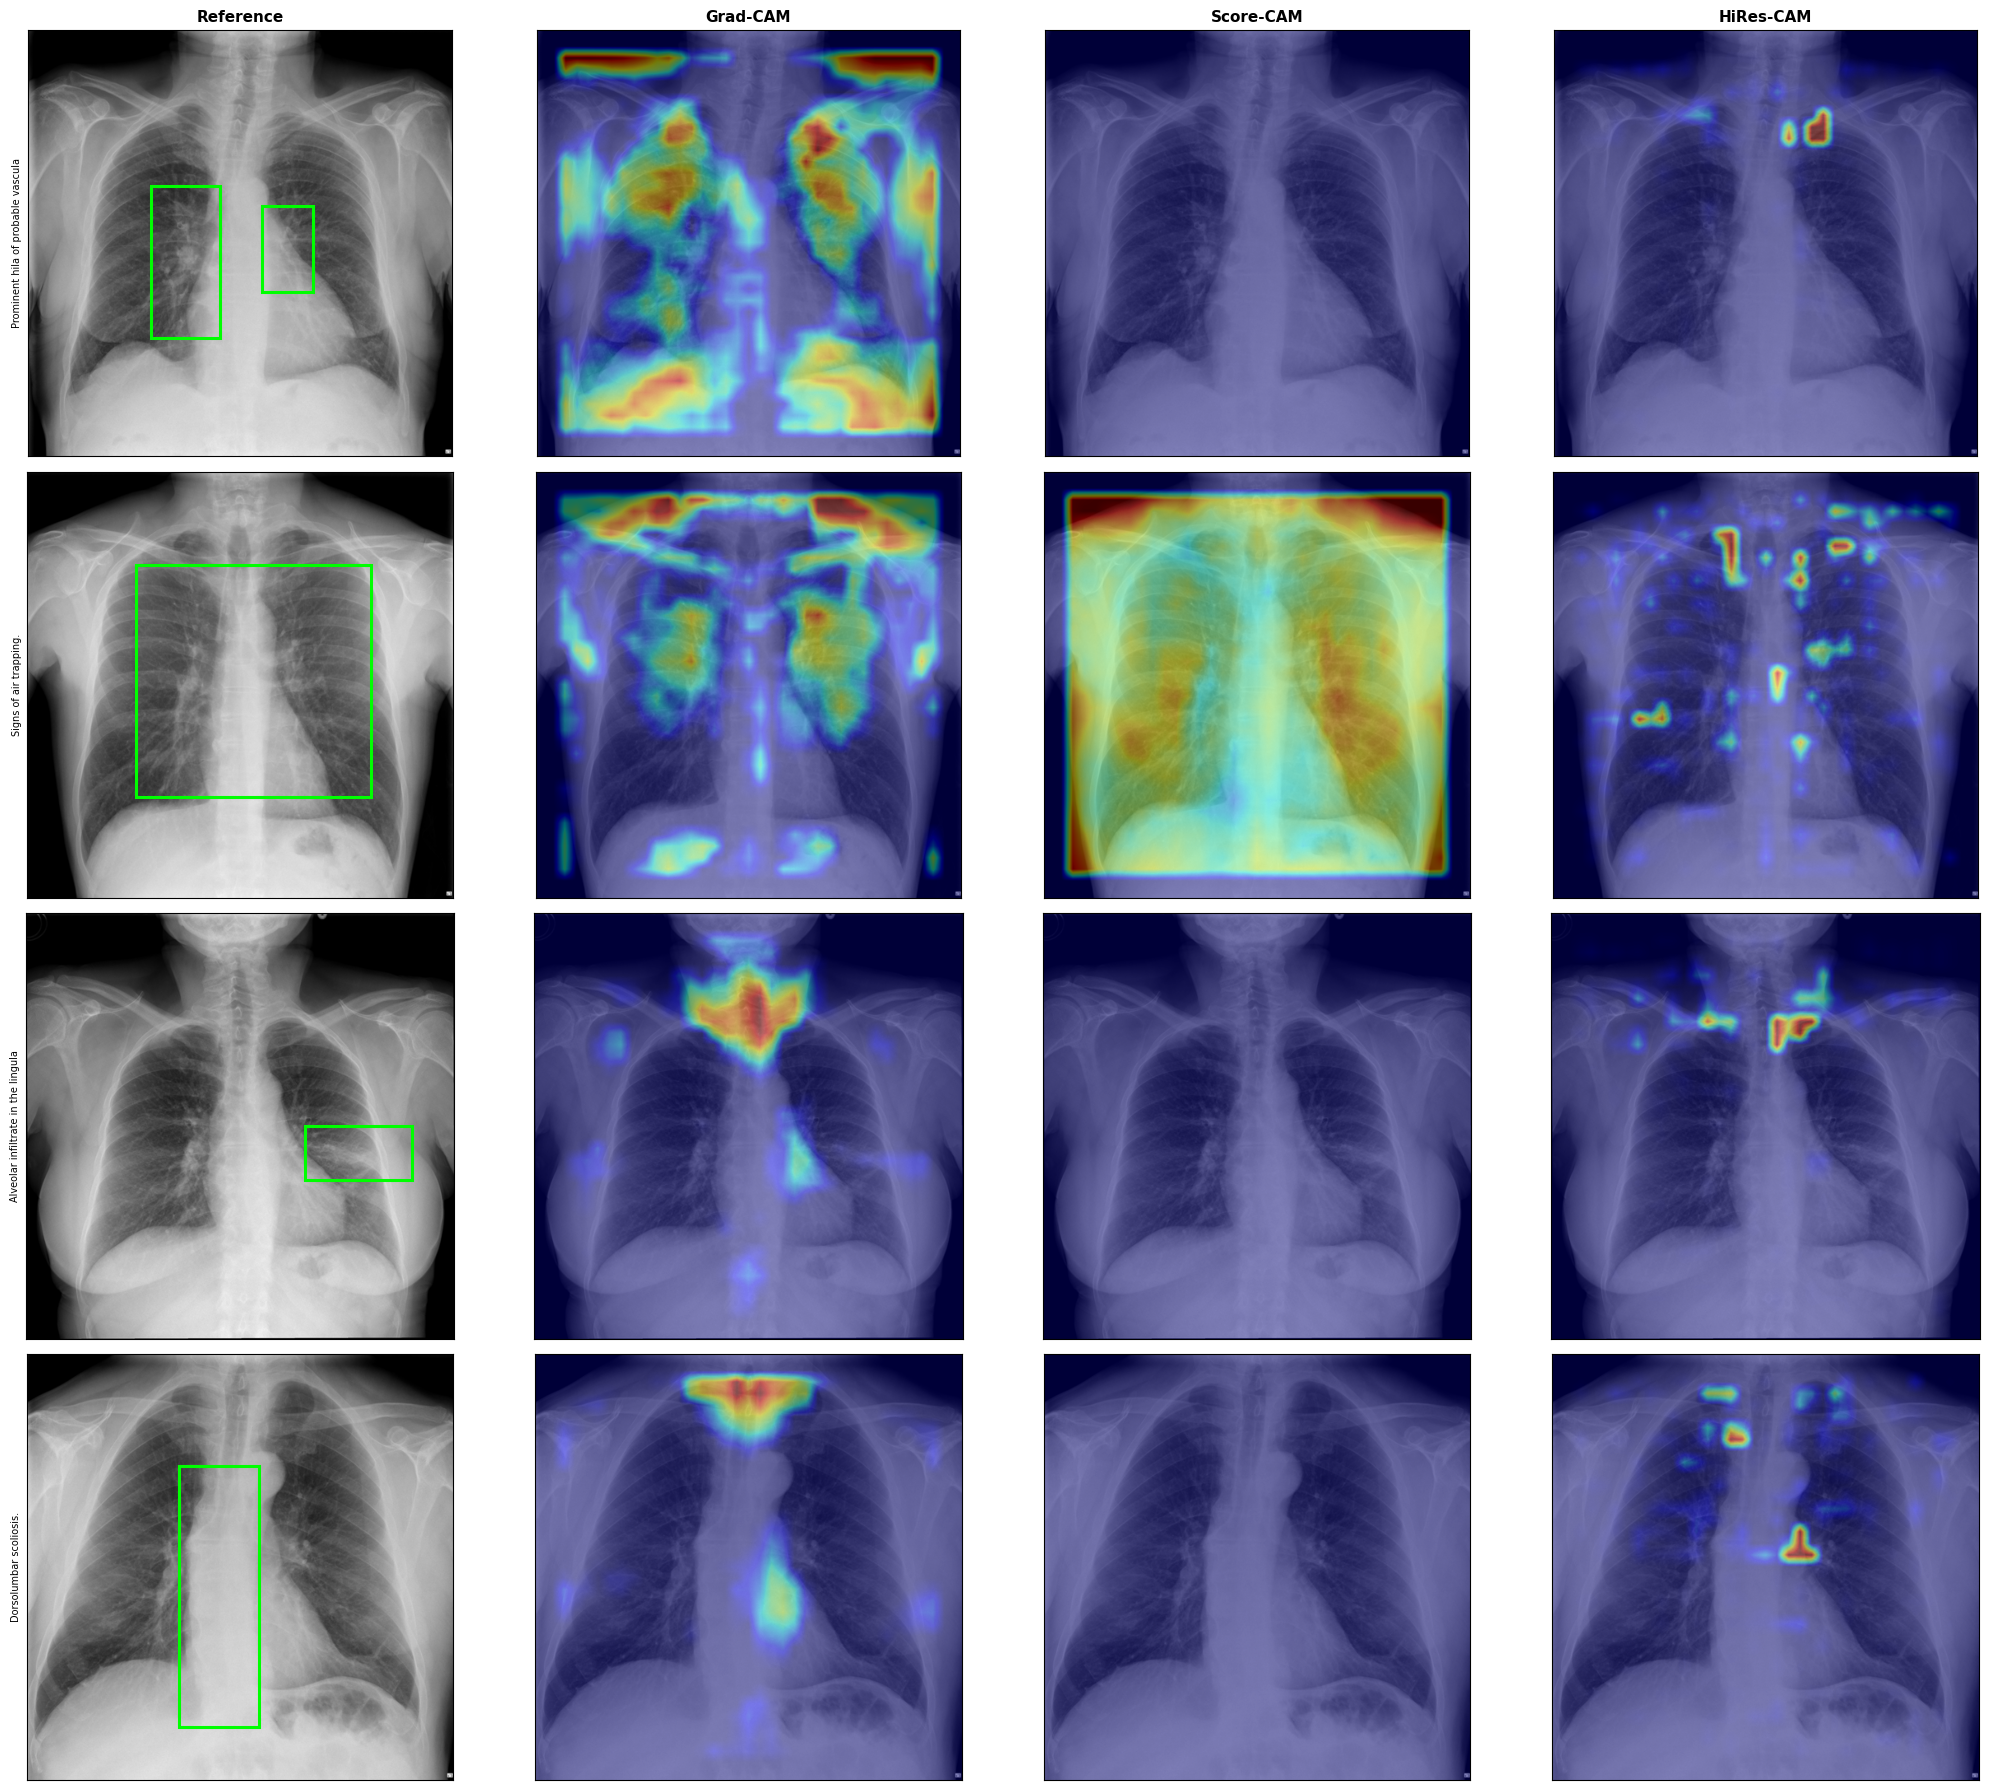

In [ ]:
# ============================================================
# QUALITATIVE COMPARISON:
# Reference | Grad-CAM | Score-CAM | HiRes-CAM
# ============================================================

# Show 4 examples with at least one ground-truth box
show = [
    s for s in te_abn
    if any(s["boxes"])
][:4]


methods = [
    ("Grad-CAM", cam_gradcam),
    ("Score-CAM", cam_scorecam),
    ("HiRes-CAM", cam_hirescam),
]

# Reference + 3 CAM methods
N_COLS = 4


fig, ax = plt.subplots(
    len(show),
    N_COLS,
    figsize=(21, 4.5 * len(show))
)

if len(show) == 1:
    ax = ax[None, :]


for r, s in enumerate(show):

    # --------------------------------------------------------
    # Pick a sentence that actually has a box
    # --------------------------------------------------------

    sent_idx = next(
        i for i, b in enumerate(s["boxes"]) if b
    )

    sent = s["sentences"][sent_idx]
    gt_boxes = s["boxes"][sent_idx]

    # First GT box is used as target for CAM generation
    gt_box = gt_boxes[0]

    img = Image.open(s["path"])
    W, H = img.size


    # ========================================================
    # COLUMN 1 — REFERENCE
    # ========================================================

    ax[r, 0].imshow(
        img,
        cmap="gray"
    )

    # Ground-truth boxes ONLY on Reference
    for g in gt_boxes:

        ax[r, 0].add_patch(
            mpatches.Rectangle(
                (g[0], g[1]),
                g[2] - g[0],
                g[3] - g[1],
                fill=False,
                ec="lime",
                lw=2.2
            )
        )

    ax[r, 0].set_ylabel(
        sent[:34],
        fontsize=7
    )

    if r == 0:
        ax[r, 0].set_title(
            "Reference",
            fontsize=11,
            fontweight="bold"
        )


    # ========================================================
    # COLUMNS 2–4 — CAM METHODS
    # ========================================================

    for c, (nm, fn) in enumerate(
        methods,
        start=1
    ):

        # ----------------------------------------------------
        # Generate attribution heatmap
        # ----------------------------------------------------

        hm = fn(
            s,
            sent,
            gt_box
        )

        if hm is None:

            ax[r, c].imshow(
                img,
                cmap="gray"
            )

            ax[r, c].text(
                0.5,
                0.5,
                "No CAM",
                transform=ax[r, c].transAxes,
                ha="center",
                va="center",
                fontsize=12
            )

        else:

            # ------------------------------------------------
            # Postprocess CAM
            # ------------------------------------------------

            hm = postprocess(hm)

            # ------------------------------------------------
            # Upsample 19x19 -> original image size
            # ------------------------------------------------

            up = F.interpolate(
                torch.from_numpy(hm)[None, None],
                size=(H, W),
                mode="bilinear",
                align_corners=False
            )[0, 0].numpy()

            # ------------------------------------------------
            # Image
            # ------------------------------------------------

            ax[r, c].imshow(
                img,
                cmap="gray"
            )

            # ------------------------------------------------
            # Heatmap ONLY
            # No bounding boxes here
            # ------------------------------------------------

            ax[r, c].imshow(
                up,
                cmap="jet",
                alpha=0.45
            )


        # ----------------------------------------------------
        # Column title
        # ----------------------------------------------------

        if r == 0:

            ax[r, c].set_title(
                nm,
                fontsize=11,
                fontweight="bold"
            )


    # ========================================================
    # REMOVE AXIS TICKS
    # ========================================================

    for c in range(N_COLS):

        ax[r, c].set_xticks([])
        ax[r, c].set_yticks([])


# ============================================================
# SAVE
# ============================================================

plt.tight_layout()

plt.savefig(
    f"{OUT_ROOT}/{RUN}/cam_qualitative_4examples.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()

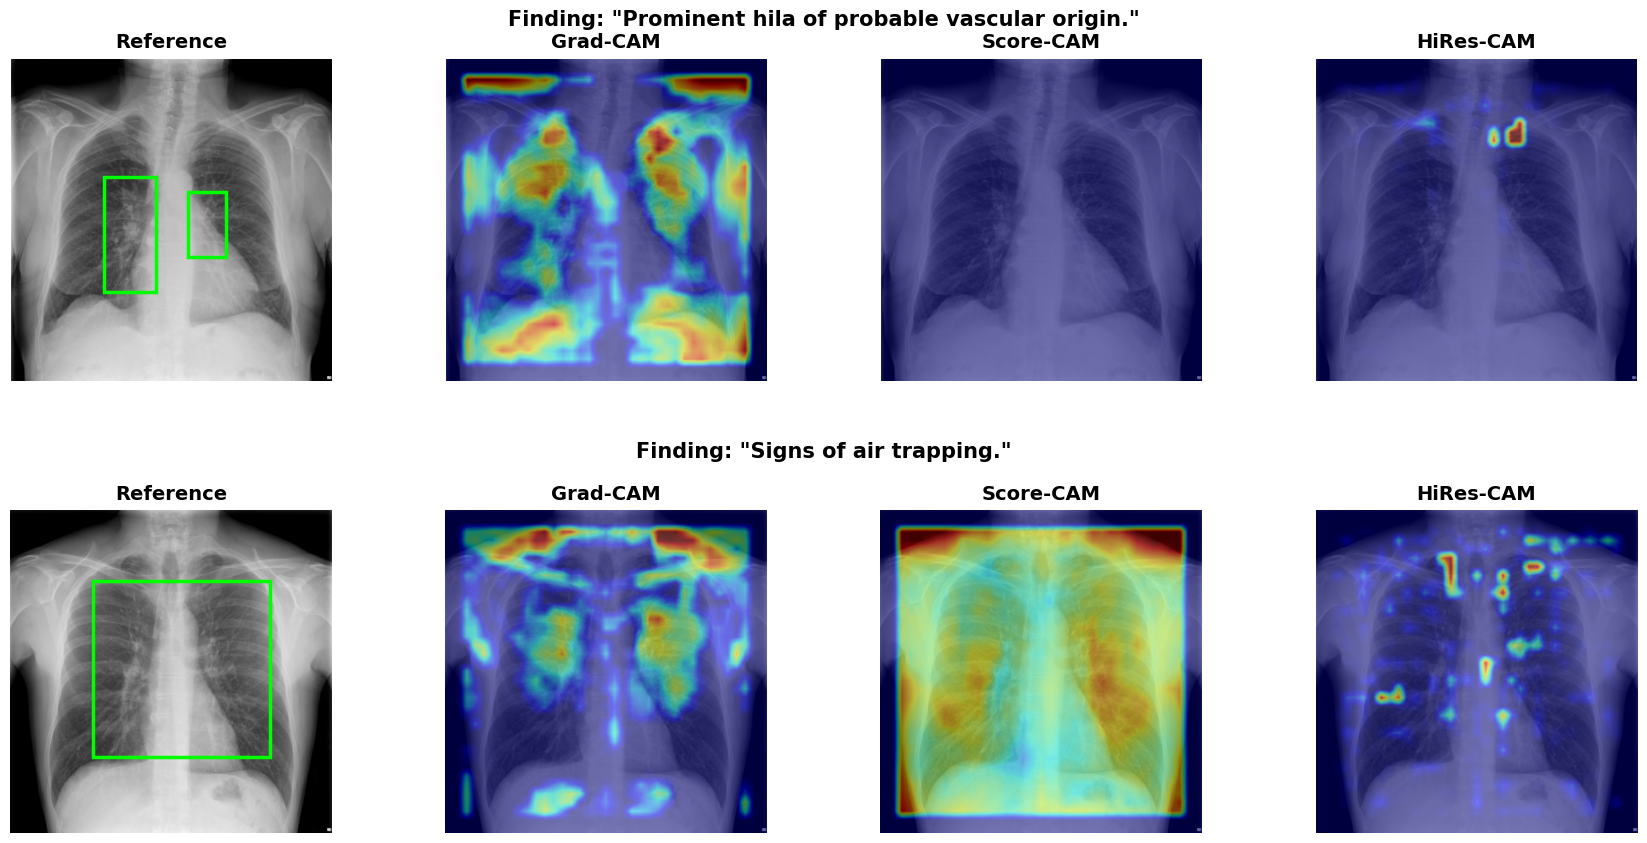

In [ ]:
# ============================================================
# QUALITATIVE COMPARISON:
# Reference | Grad-CAM | Score-CAM | HiRes-CAM
# 2 examples with large finding text
# ============================================================

show = [
    s for s in te_abn
    if any(s["boxes"])
][:2]

methods = [
    ("Grad-CAM", cam_gradcam),
    ("Score-CAM", cam_scorecam),
    ("HiRes-CAM", cam_hirescam),
]

N_COLS = 4

fig, ax = plt.subplots(
    len(show),
    N_COLS,
    figsize=(18, 9)
)

if len(show) == 1:
    ax = ax[None, :]


for r, s in enumerate(show):

    # --------------------------------------------------------
    # Select a sentence with a ground-truth box
    # --------------------------------------------------------

    sent_idx = next(
        i for i, b in enumerate(s["boxes"]) if b
    )

    sent = s["sentences"][sent_idx]
    gt_boxes = s["boxes"][sent_idx]
    gt_box = gt_boxes[0]

    img = Image.open(s["path"])
    W, H = img.size

    # ========================================================
    # FINDING TEXT — LARGE
    # ========================================================

    if r == 0:
        y_text = 0.965
    else:
        y_text = 0.485

    fig.text(
        0.5,
        y_text,
        f'Finding: "{sent}"',
        ha="center",
        va="top",
        fontsize=15,
        fontweight="bold"
    )

    # ========================================================
    # REFERENCE
    # ========================================================

    ax[r, 0].imshow(
        img,
        cmap="gray"
    )

    for g in gt_boxes:

        ax[r, 0].add_patch(
            mpatches.Rectangle(
                (g[0], g[1]),
                g[2] - g[0],
                g[3] - g[1],
                fill=False,
                ec="lime",
                lw=2.5
            )
        )

    # Heading for BOTH examples
    ax[r, 0].set_title(
        "Reference",
        fontsize=14,
        fontweight="bold",
        pad=8
    )

    ax[r, 0].axis("off")

    # ========================================================
    # CAM METHODS
    # ========================================================

    for c, (nm, fn) in enumerate(
        methods,
        start=1
    ):

        hm = fn(
            s,
            sent,
            gt_box
        )

        if hm is None:

            ax[r, c].imshow(
                img,
                cmap="gray"
            )

            ax[r, c].text(
                0.5,
                0.5,
                "No CAM",
                transform=ax[r, c].transAxes,
                ha="center",
                va="center",
                fontsize=14
            )

        else:

            hm = postprocess(hm)

            up = F.interpolate(
                torch.from_numpy(hm)[None, None],
                size=(H, W),
                mode="bilinear",
                align_corners=False
            )[0, 0].numpy()

            ax[r, c].imshow(
                img,
                cmap="gray"
            )

            ax[r, c].imshow(
                up,
                cmap="jet",
                alpha=0.50
            )

        # Heading for BOTH examples
        ax[r, c].set_title(
            nm,
            fontsize=14,
            fontweight="bold",
            pad=8
        )

        ax[r, c].axis("off")


# ============================================================
# LAYOUT
# ============================================================

plt.subplots_adjust(
    left=0.02,
    right=0.98,
    top=0.91,
    bottom=0.05,
    wspace=0.03,
    hspace=0.40
)

# ============================================================
# SAVE
# ============================================================

plt.savefig(
    f"{OUT_ROOT}/{RUN}/cam_qualitative_2examples.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()